Самостоятельная работа Задания 1-5

Задание 1

In [75]:
from math import cos, acos, log, sin
from matplotlib.pyplot import *
from scipy import optimize

Наши корни:
Корень 1: x = -7.8500
Корень 2: x = -4.7500
Корень 3: x = -1.3500
Корень 4: x = 0.6500


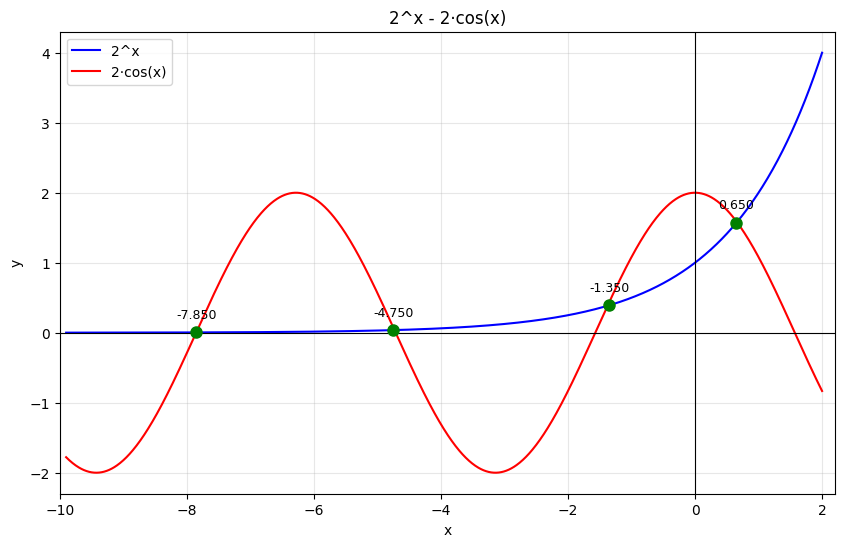

In [76]:
# первая часть
def f1(x):
    return 2**x

# вторая 
def f2(x):
    return 2 * cos(x)

# полное выражение
def f(x):
    return f1(x) - f2(x)

# отделение корней
roots = []
step = 0.1
x = -9.9  # x > -10

while x <= 2:
    if f(x) * f(x + step) < 0:  # смена знака
        root = x + step / 2  # приблизительный корень
        roots.append(root)
    x += step

# вывод корней
print("Наши корни:")
for i, r in enumerate(roots, 1):
    print(f"Корень {i}: x = {r:.4f}")

# построение графика
x_vals = [i / 100 for i in range(-990, 201)]  # от -9.9 до 2.0(после 2 график устремляется вверх, и не имеет схождения с вторым)
y1_vals = [f1(x) for x in x_vals]  # 2^x
y2_vals = [f2(x) for x in x_vals]  # 2*cos(x)

figure(figsize=(10, 6))
plot(x_vals, y1_vals, 'b-', linewidth=1.5, label='2^x')
plot(x_vals, y2_vals, 'r-', linewidth=1.5, label='2·cos(x)')
axhline(y=0, color='k', linestyle='-', linewidth=0.8)
axvline(x=0, color='k', linestyle='-', linewidth=0.8)

# отмечаем корни на графике (точки пересечения)
for r in roots:
    plot(r, f1(r), 'go', markersize=8)  # зеленые точки в местах пересечения
    text(r, f1(r) + 0.2, f'{r:.3f}', ha='center', fontsize=9)

xlim(-10, 2.2)
grid(True, alpha=0.3)
xlabel('x')
ylabel('y')
title('2^x - 2·cos(x)')
legend()
show()

Задание 2

In [77]:
# наша функция
def f(x):
    return 2**x - 2 * cos(x)

# начальный промежуток с корнем и точность
a = 0.0
b = 1.0
eps = 1e-3

# создаём заглавие таблицы
print(f"{'Итерация':^10} {'a':^12} {'b':^12} {'c':^12}")

# первая итерация ии циикл, пока не будет условие меньше точности
iteration = 0
while (b - a) / 2 > eps:
    c = (a + b) / 2
    
    print(f"{iteration:^10} {a:^12.6f} {b:^12.6f} {c:^12.6f}")
    
    if f(a) * f(c) < 0:
        b = c
    else:
        a = c
    
    iteration += 1

c = (a + b) / 2
print(f"{iteration:^10} {a:^12.6f} {b:^12.6f} {c:^12.6f}")

print(f"Наш корень: x = {c:.6f}")

 Итерация       a            b            c      
    0        0.000000     1.000000     0.500000  
    1        0.500000     1.000000     0.750000  
    2        0.500000     0.750000     0.625000  
    3        0.625000     0.750000     0.687500  
    4        0.625000     0.687500     0.656250  
    5        0.656250     0.687500     0.671875  
    6        0.656250     0.671875     0.664062  
    7        0.656250     0.664062     0.660156  
    8        0.656250     0.660156     0.658203  
    9        0.658203     0.660156     0.659180  
Наш корень: x = 0.659180


Задание 3

In [78]:

def f(x):
    return 2**x - 2 * cos(x)

# фунцкия для итерации
def it_f(x):
    return acos(2**(x-1))

x0 = 0.5  # начальное приближение в интервале [0, 1]
eps = 1e-6

print(f"{'Номер итерации':^10} {'x_n':^12} {'x_n+1':^12} {'Точность':^20}")

x_prev = x0
iteration = 0
error = 1

while error > eps:
    x_next = it_f(x_prev)
    error = abs(x_next - x_prev)
    
    print(f"{iteration:^13} {x_prev:^13.6f} {x_next:^13.6f} {error:^20.6f}")
    
    x_prev = x_next
    iteration += 1

print(f"Итерация с нужной точностью: {iteration-1}")
print(f"Корень: x = {x_next:.6f}")

Номер итерации     x_n         x_n+1           Точность      
      0         0.500000      0.785398          0.285398      
      1         0.785398      0.532020          0.253378      
      2         0.532020      0.762696          0.230675      
      3         0.762696      0.557975          0.204720      
      4         0.557975      0.743505          0.185529      
      5         0.743505      0.578801          0.164704      
      6         0.578801      0.727553          0.148752      
      7         0.727553      0.595418          0.132136      
      8         0.595418      0.714448          0.119030      
      9         0.714448      0.608638          0.105810      
     10         0.608638      0.703768          0.095130      
     11         0.703768      0.619142          0.084626      
     12         0.619142      0.695114          0.075972      
     13         0.695114      0.627486          0.067628      
     14         0.627486      0.688130          0.060644

Задание 4


In [ ]:
# наша функциия
def f(x):
    return 2**x - 2 * cos(x)

# производная функции
def df(x):
    return 2**x * log(2) + 2 * sin(x)


# комбинированный метод хорд и касательных
a = 0.0
b = 1.0
eps = 1e-6

print(f"{'Итерация':^10} {'a':^12} {'b':^12} {'x':^12}")

iteration = 0
x_prev = a

while True:
    # метод хорд
    x_chord = a - f(a) * (b - a) / (f(b) - f(a))
    
    # метод касательных (ньютона)
    x_tan = x_prev - f(x_prev) / df(x_prev)
    
    # комбинируем - берем среднее
    x = (x_chord + x_tan) / 2
    
    fx = f(x)
    
    print(f"{iteration:^10} {a:^12.8f} {b:^12.8f} {x:^12.8f}")
    
    if abs(fx) < eps:
        break
    
    # обновляем границы для метода хорд
    if f(a) * fx < 0:
        b = x
    else:
        a = x
    
    x_prev = x
    iteration += 1

print(f"Корень: x = {x:.8f}")


 Итерация       a            b            x      
    0       0.00000000   1.00000000   0.98184622 
    1       0.00000000   0.98184622   0.61180960 
    2       0.61180960   0.98184622   0.65723731 
    3       0.65723731   0.98184622   0.65977545 
    4       0.65977545   0.98184622   0.65994540 
    5       0.65994540   0.98184622   0.65995688 
    6       0.65995688   0.98184622   0.65995766 
Корень: x = 0.65995766


Зданаие 5

In [ ]:
# решение с помощью SciPy (инструментальный пакет)
# производная функции
def df(x):
    return 2**x * log(2) + 2 * sin(x)

# решаю по методу ньютона в пакете
result = optimize.newton(f, 0.5, fprime=df, tol=1e-6, full_output=True)
root = result[0]

print(f"Корень: x = {root:.8f}")
print(f"Количество итераций: {result[1].iterations}")

Корень: x = 0.65995772
Количество итераций: 4


Как итог, самый быстрый и лучший способ для нахождения корней - использование пакетов, они не трудно настраиваются и экономят ресурсы системы.

Но еслии использовать программные коды, без пакетов, то лучший - кобминированный метод хор и касательных - он прост в понимании кодом, и крайне просто пишется

Для ручного решениия я бы использовал метод половинного деления, он для меня самый простой на бумаге, и в нем труднее всего запутаться
